In [1]:
import numpy as np
import skimage as sk
import skimage.io as skio
import matplotlib.pyplot as plt
from skimage import transform, exposure, filters
from scipy.signal import convolve2d

import os
import cv2
from PIL import Image 



In [2]:
def load_image(image_path): 
      return skio.imread(image_path)

In [3]:
#Part 1.1 Comvolutions from Scratch

def convolution(image, filter): 
    img_h, img_w = image.shape
    filter_h, filter_w = filter.shape

    pad_h = filter_h//2
    pad_w = filter_w//2

    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), 
                            mode='constant', constant_values=0)
    
    output = np.zeros((img_h, img_w))

    for i in range(img_h): 
        for j in range(img_w): 
            #simplified into 2 for loops by slicing 
            process = padded_image[i:i+filter_h, j:j+filter_w]
            output[i, j] = np.sum(process * filter)
    return output


def box9by9(): 
    return np.ones((9, 9)) / 81.0 

def diff_op_x():
    return np.array([[0, 0, 0],
                     [-1, 0, 1],
                     [0, 0, 0]])

def diff_op_y():
    return np.array([[0, -1, 0],
                     [0, 0, 0],
                     [0, 1, 0]])


Testing with real image:


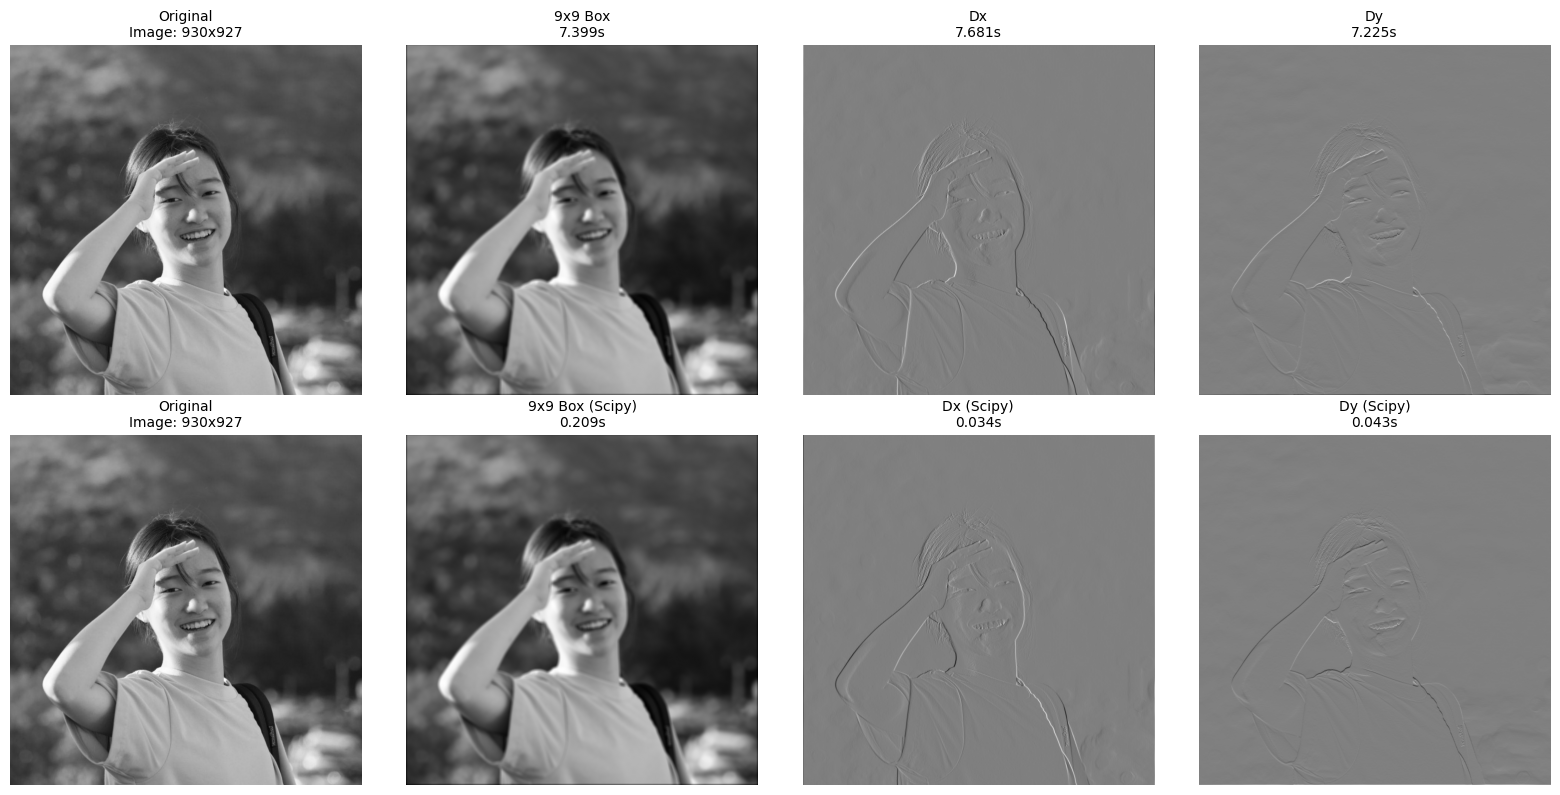


Value ranges:
Original: [3.000, 255.000]
Dx Our: [-161.000, 174.000]
Dy Our: [-241.000, 177.000]
Dx Scipy: [-174.000, 161.000]
Dy Scipy: [-177.000, 241.000]

Mean absolute differences:
Box filter: 0.000000
Dx filter: 5.879050
Dy filter: 5.744988


In [4]:
import time
def safe_save_image(image_data, filename, is_derivative):
    """Save image properly handling different data types and ranges"""
    if image_data.dtype == bool:
        image_uint8 = image_data.astype(np.uint8) * 255
    else:
        # For derivative images, use symmetric normalization around zero
        if is_derivative:
            # For derivative filters, preserve zero as middle gray
            max_val = max(abs(image_data.max()), abs(image_data.min()))
            if max_val > 0:
                # Normalize to [-1, 1] then scale to [0, 255] with 128 as zero
                image_normalized = (image_data / max_val + 1) * 127.5
            else:
                image_normalized = np.full_like(image_data, 128)  # All gray if no variation
        else:
            # For regular images, normalize from min to max
            if image_data.max() > image_data.min():
                image_normalized = (image_data - image_data.min()) / (image_data.max() - image_data.min()) * 255
            else:
                image_normalized = np.full_like(image_data, 128)
    
    image_uint8 = np.clip(image_normalized, 0, 255).astype(np.uint8)
    skio.imsave(filename, image_uint8)

def process_image(image_path):
    img = np.array(Image.open(image_path).convert('L')).astype(np.float64)
    
    box_9x9 = box9by9()
    dx = diff_op_x()
    dy = diff_op_y()
    
    runtimes = {}

    # Our 
    start_time = time.time()
    box_filtered = convolution(img, box_9x9)
    runtimes['our_box'] = time.time() - start_time

    start_time = time.time()
    dx_filtered = convolution(img, dx)
    runtimes['our_dx'] = time.time() - start_time

    start_time = time.time()
    dy_filtered = convolution(img, dy)
    runtimes['our_dy'] = time.time() - start_time
    
    # Scipy 
    start_time = time.time()
    box_scipy = convolve2d(img, box_9x9, mode='same', boundary='fill', fillvalue=0)
    runtimes['scipy_box'] = time.time() - start_time

    start_time = time.time()
    dx_scipy = convolve2d(img, dx, mode='same', boundary='fill', fillvalue=0)
    runtimes['scipy_dx'] = time.time() - start_time

    start_time = time.time()
    dy_scipy = convolve2d(img, dy, mode='same', boundary='fill', fillvalue=0)
    runtimes['scipy_dy'] = time.time() - start_time

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    images = [img, box_filtered, dx_filtered, dy_filtered,
              img, box_scipy, dx_scipy, dy_scipy]
    
    titles = [
        f'Original\nImage: {img.shape[1]}x{img.shape[0]}',
        f'9x9 Box\n{runtimes["our_box"]:.3f}s',
        f'Dx\n{runtimes["our_dx"]:.3f}s', 
        f'Dy\n{runtimes["our_dy"]:.3f}s',
        f'Original\nImage: {img.shape[1]}x{img.shape[0]}',
        f'9x9 Box (Scipy)\n{runtimes["scipy_box"]:.3f}s',
        f'Dx (Scipy)\n{runtimes["scipy_dx"]:.3f}s',
        f'Dy (Scipy)\n{runtimes["scipy_dy"]:.3f}s'
    ]
    
    for i, (ax, img_data, title) in enumerate(zip(axes.flat, images, titles)):
        # Use different display scaling for derivative images
        if 'Dx' in title or 'Dy' in title:
            # For derivatives, use symmetric scaling around zero
            vmax = max(abs(img_data.max()), abs(img_data.min()))
            vmin = -vmax if vmax > 0 else img_data.min()
            im = ax.imshow(img_data, cmap='gray', vmin=vmin, vmax=vmax)
        else:
            # For regular images, use auto-scaling
            im = ax.imshow(img_data, cmap='gray')
        
        ax.set_title(title, fontsize=10)
        ax.axis('off')
        
    
    plt.tight_layout()
    out_dir = "../web/photos"
    os.makedirs(out_dir, exist_ok=True)
    
    comparison_fig_path = os.path.join(out_dir, f"convolution_comparison_{int(time.time())}.jpg")
    
    # Save individual images with proper handling
    image_info = [
        ("original", img, False),           # Not a derivative
        ("box_our", box_filtered, False),   # Not a derivative  
        ("dx_our", dx_filtered, True),      # Is a derivative
        ("dy_our", dy_filtered, True),      # Is a derivative
        ("box_scipy", box_scipy, False),    # Not a derivative
        ("dx_scipy", dx_scipy, True),       # Is a derivative
        ("dy_scipy", dy_scipy, True)        # Is a derivative
    ]
    
    base_time = int(time.time())
    for name, image_data, is_derivative in image_info:
        filename = os.path.join(out_dir, f"1.1_{name}_{base_time}.jpg")
        safe_save_image(image_data, filename, is_derivative)
        
        
    
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    
    # Print value ranges for debugging
    print("\nValue ranges:")
    print(f"Original: [{img.min():.3f}, {img.max():.3f}]")
    print(f"Dx Our: [{dx_filtered.min():.3f}, {dx_filtered.max():.3f}]")
    print(f"Dy Our: [{dy_filtered.min():.3f}, {dy_filtered.max():.3f}]")
    print(f"Dx Scipy: [{dx_scipy.min():.3f}, {dx_scipy.max():.3f}]")
    print(f"Dy Scipy: [{dy_scipy.min():.3f}, {dy_scipy.max():.3f}]")
    
    # Calculate differences
    print("\nMean absolute differences:")
    print(f"Box filter: {np.mean(np.abs(box_filtered - box_scipy)):.6f}")
    print(f"Dx filter: {np.mean(np.abs(dx_filtered - dx_scipy)):.6f}")
    print(f"Dy filter: {np.mean(np.abs(dy_filtered - dy_scipy)):.6f}")


print("Testing with real image:")
process_image('../data/1_1profile.jpg')

Testing with real image:


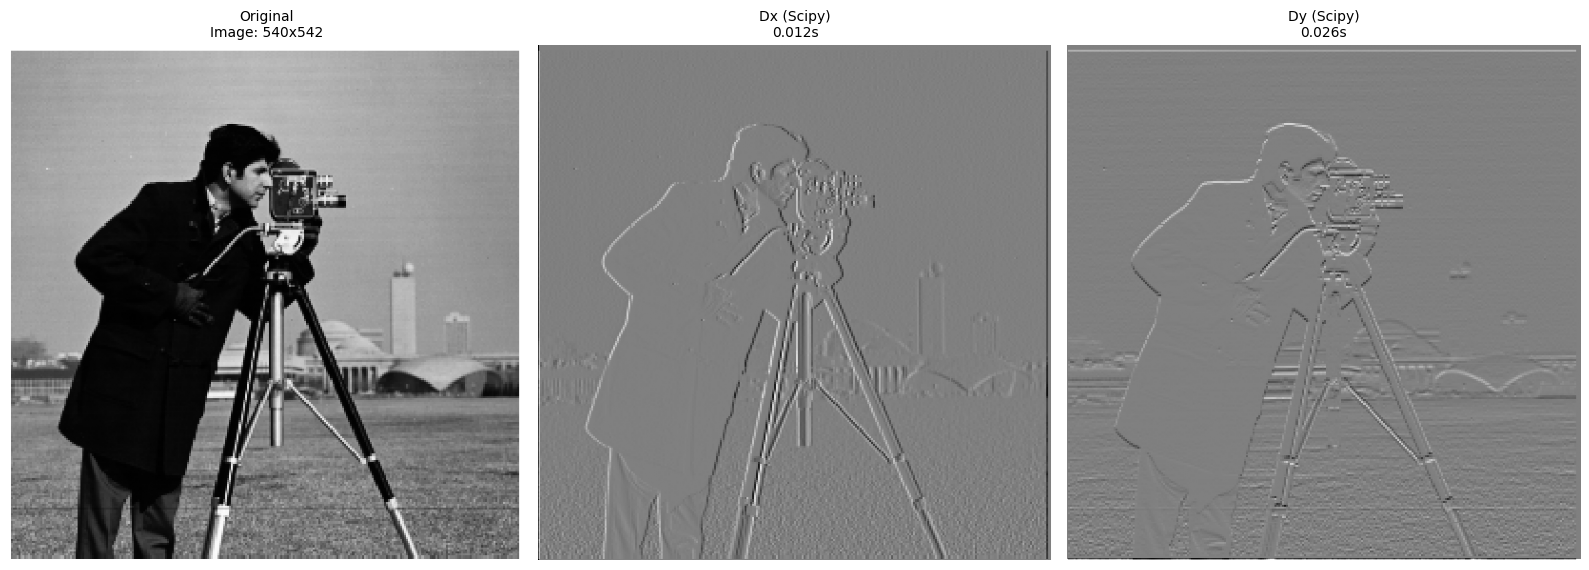

In [5]:
#part 1.2 

def process_image_cameraman(image_path):
    img = np.array(Image.open(image_path).convert('L')).astype(np.float64)
    
    dx = diff_op_x()
    dy = diff_op_y()
    
    runtimes = {}

    start_time = time.time()
    dx_scipy = convolve2d(img, dx, mode='same', boundary='fill', fillvalue=0)
    runtimes['scipy_dx'] = time.time() - start_time

    start_time = time.time()
    dy_scipy = convolve2d(img, dy, mode='same', boundary='fill', fillvalue=0)
    runtimes['scipy_dy'] = time.time() - start_time

    fig, axes = plt.subplots(1, 3, figsize=(16, 8))
    
    images = [img, dx_scipy, dy_scipy]
    
    titles = [
        f'Original\nImage: {img.shape[1]}x{img.shape[0]}',
        f'Dx (Scipy)\n{runtimes["scipy_dx"]:.3f}s',
        f'Dy (Scipy)\n{runtimes["scipy_dy"]:.3f}s'
    ]
    
    for i, (ax, img_data, title) in enumerate(zip(axes.flat, images, titles)):
        # Use different display scaling for derivative images
        if 'Dx' in title or 'Dy' in title:
            # For derivatives, use symmetric scaling around zero
            vmax = max(abs(img_data.max()), abs(img_data.min()))
            vmin = -vmax if vmax > 0 else img_data.min()
            im = ax.imshow(img_data, cmap='gray', vmin=vmin, vmax=vmax)
        else:
            # For regular images, use auto-scaling
            im = ax.imshow(img_data, cmap='gray')
        
        ax.set_title(title, fontsize=10)
        ax.axis('off')
        
    
    plt.tight_layout()
    out_dir = "../web/photos"
    os.makedirs(out_dir, exist_ok=True)
    
    comparison_fig_path = os.path.join(out_dir, f"convolution_comparison_{int(time.time())}.jpg")
    
    # Save individual images with proper handling
    image_info = [
        ("dx_scipy", dx_scipy, True),       # Is a derivative
        ("dy_scipy", dy_scipy, True)        # Is a derivative
    ]
    
    base_time = int(time.time())
    for name, image_data, is_derivative in image_info:
        filename = os.path.join(out_dir, f"1.2_finiteDifference_{name}_{base_time}.jpg")
        safe_save_image(image_data, filename, is_derivative)
        
        
    
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    

print("Testing with real image:")
process_image_cameraman('../data/cameraman.png')

In [6]:
def safe_save_image(image_data, filename):
    """
    Save image properly - handles boolean arrays for black/white edge images
    """
    if image_data.dtype == bool:
        # Convert boolean to uint8: True=255 (white edges), False=0 (black background)
        image_uint8 = image_data.astype(np.uint8) * 255
    else:
        # For other types, use existing conversion
        if image_data.dtype in [np.float32, np.float64]:
            # Normalize float to 0-255 range
            if image_data.max() > image_data.min():
                image_normalized = (image_data - image_data.min()) / (image_data.max() - image_data.min()) * 255
            else:
                image_normalized = np.full_like(image_data, 128)
            image_uint8 = np.clip(image_normalized, 0, 255).astype(np.uint8)
        else:
            image_uint8 = image_data.astype(np.uint8)
    
    skio.imsave(filename, image_uint8)

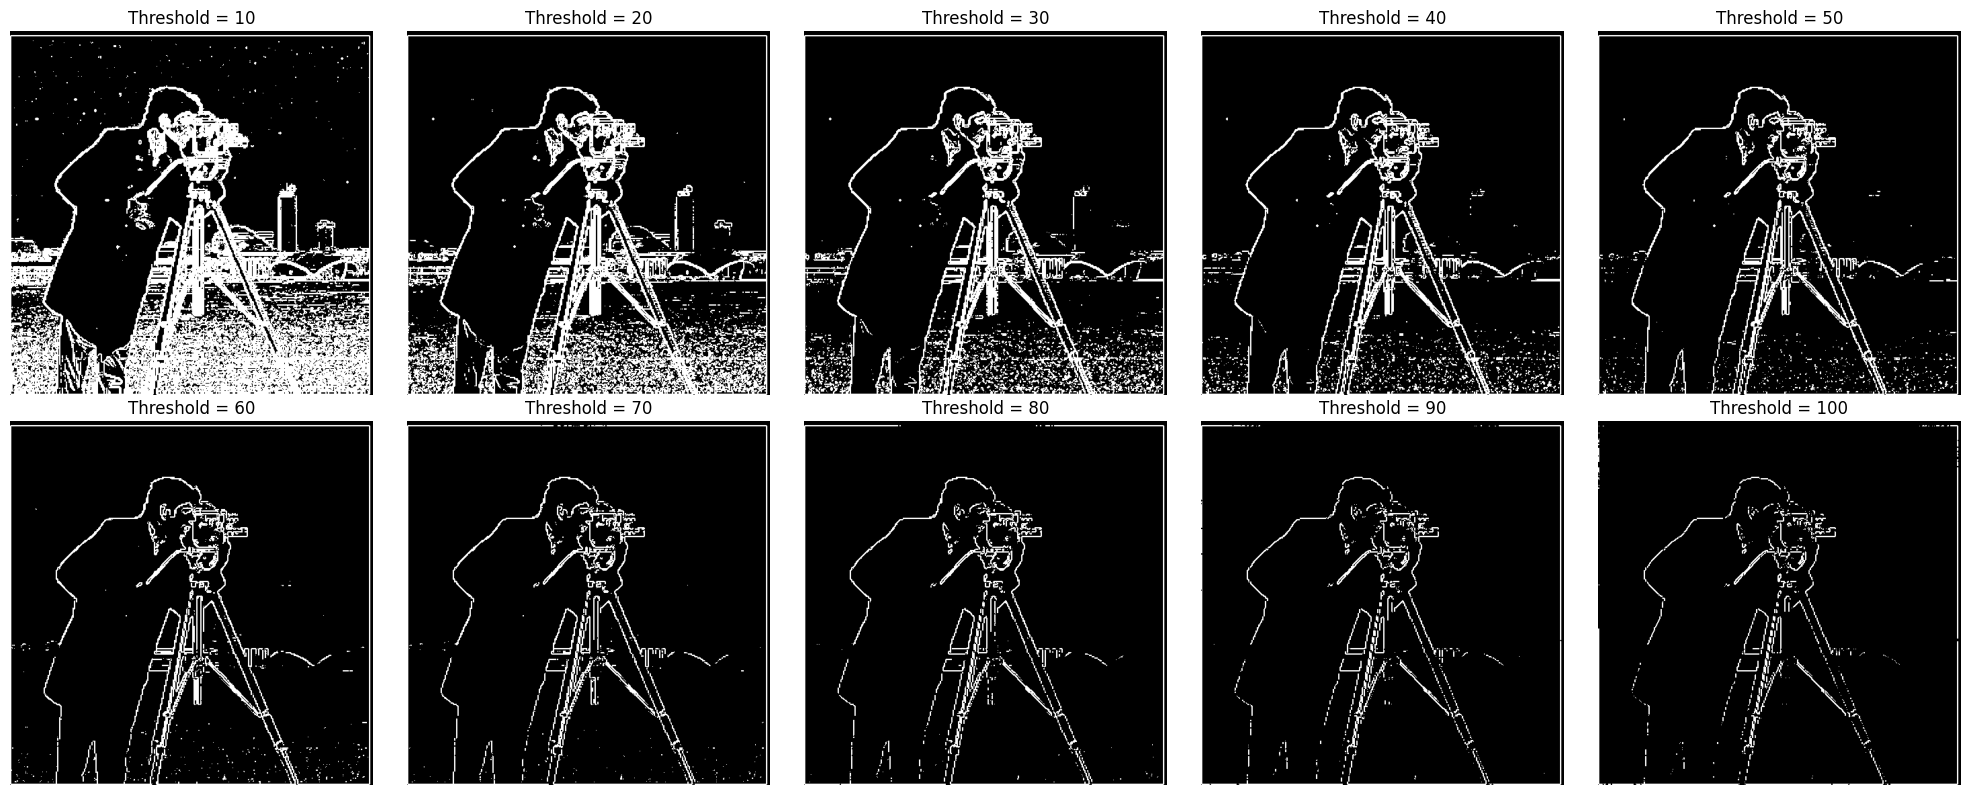

In [ ]:
def part_1_2_edge_magnitude(img): 
    Dx = np.array([[0, 0, 0],
                   [-1, 0, 1], 
                   [0, 0, 0]])   
    
    Dy = np.array([[0, -1, 0],
                   [0, 0, 0],
                   [0, 1, 0]]) 
    
 
    Ix = convolve2d(img, Dx, mode='same', boundary='symm')
    Iy = convolve2d(img, Dy, mode='same', boundary='symm')
    
    gradient_magnitude = np.sqrt(Ix**2 + Iy**2)
    return gradient_magnitude

def part_1_2_edge_detection_display(img):
    
    gradient_magnitude = part_1_2_edge_magnitude(img)
    
    thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flat
    
    for i, threshold in enumerate(thresholds):
        edge_image = gradient_magnitude > threshold
        
        axes[i].imshow(edge_image, cmap='gray')
        axes[i].set_title(f'Threshold = {threshold}')
        axes[i].axis('off')
    
    plt.tight_layout()
    
    out_dir = "../web/photos"
    os.makedirs(out_dir, exist_ok=True)
    
    
    base_time = int(time.time())
    # filename = os.path.join(out_dir, f"1.2_magnitude_{base_time}.jpg")
    # safe_save_image(gradient_magnitude, filename, False)
        
        
    filename = os.path.join(out_dir, f"best_magnitude{base_time}.jpg")
    best_edge = gradient_magnitude > 85
    #safe_save_image(best_edge, filename)


    comparison_fig_path = os.path.join(out_dir, f"edge_comparison_{int(time.time())}.jpg")
    # #plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    
    


img = np.array(Image.open('../data/cameraman.png').convert('L')).astype(np.float64)
part_1_2_edge_detection_display(img)
    


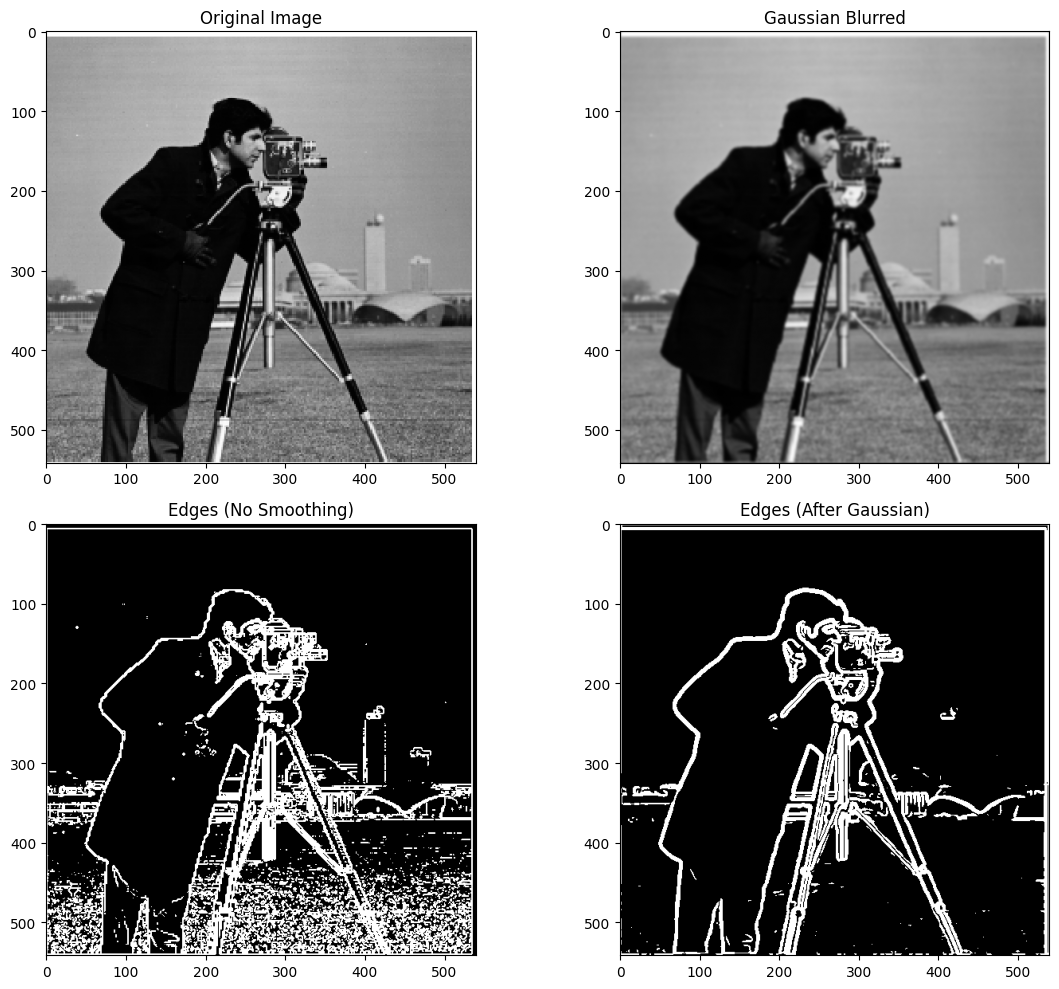

In [ ]:
def gaussian_filter(sigma=1.5, size=9):
    gaussian1D = cv2.getGaussianKernel(size, sigma) 
    gaussian2D = np.outer(gaussian1D, gaussian1D.T)
    return gaussian2D

def DoG(image_path): 
    img = np.array(Image.open(image_path).convert('L')).astype(np.float64)

    #original 
    edges_original = part_1_2_edge_magnitude(img) > 20


    #blurred
    gaus_filter = gaussian_filter(sigma=1.5, size=9)
    blurred = convolve2d(img, gaus_filter, mode='same')
    edges_blurred = part_1_2_edge_magnitude(blurred) > 20

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0,0].imshow(img, cmap='gray')
    axes[0,0].set_title('Original Image')
    
    axes[0,1].imshow(blurred, cmap='gray')
    axes[0,1].set_title('Gaussian Blurred')
    
    axes[1,0].imshow(edges_original, cmap='gray')
    axes[1,0].set_title('Edges (No Smoothing)')
    
    axes[1,1].imshow(edges_blurred, cmap='gray')
    axes[1,1].set_title('Edges (After Gaussian)')
    


    plt.tight_layout()
    
    out_dir = "../web/photos"
    comparison_fig_path = os.path.join(out_dir, f"DoG_{int(time.time())}.jpg")
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

    plt.show()

DoG('../data/cameraman.png')

    

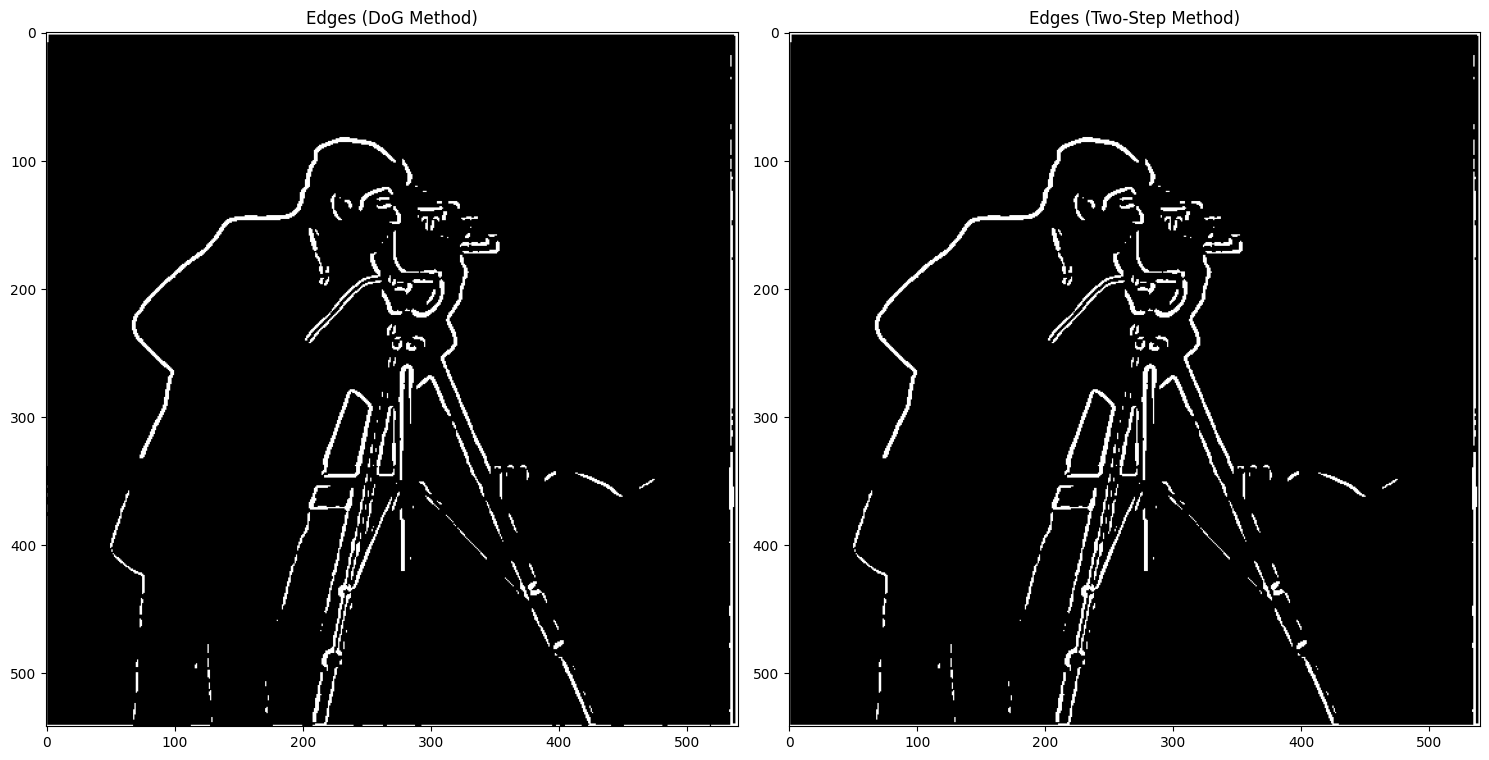

In [9]:
#Part1.3 DoG part 2: single convolution 

def DoG_part2(image_path):
    img = np.array(Image.open(image_path).convert('L')).astype(np.float64)
    
    gaussian = gaussian_filter(sigma=1.5, size=9)
    Dx = np.array([[0, 0, 0], [-1, 0, 1], [0, 0, 0]]) 
    Dy = np.array([[0, -1, 0], [0, 0, 0], [0, 1, 0]]) 
    
    # Convolve Gaussian with derivatives to get DoG filters
    DoG_x = convolve2d(gaussian, Dx, mode='full') 
    DoG_y = convolve2d(gaussian, Dy, mode='full')  
    
    Ix_dog = convolve2d(img, DoG_x, mode='same')
    Iy_dog = convolve2d(img, DoG_y, mode='same')
    edges_dog = np.sqrt(Ix_dog**2 + Iy_dog**2) > 50 
    

    gaussian = gaussian_filter(sigma=1.5, size=9)
    blurred = convolve2d(img, gaussian, mode='same')
    Ix_two_step = convolve2d(blurred, Dx, mode='same')
    Iy_two_step = convolve2d(blurred, Dy, mode='same')
    edges_two_step = np.sqrt(Ix_two_step**2 + Iy_two_step**2) > 50
    
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))
    
    axes[0].imshow(edges_dog, cmap='gray')
    axes[0].set_title('Edges (DoG Method)')
    
    axes[1].imshow(edges_two_step, cmap='gray')
    axes[1].set_title('Edges (Two-Step Method)')
    
    
    plt.tight_layout()
    
    out_dir = "../web/photos"
    comparison_fig_path = os.path.join(out_dir, f"DoG_two_method_{int(time.time())}.jpg")
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

    plt.show()

# Complete function
def DoG_complete(image_path):
    #DoG(image_path)  
    DoG_part2(image_path)  

DoG_complete('../data/cameraman.png')

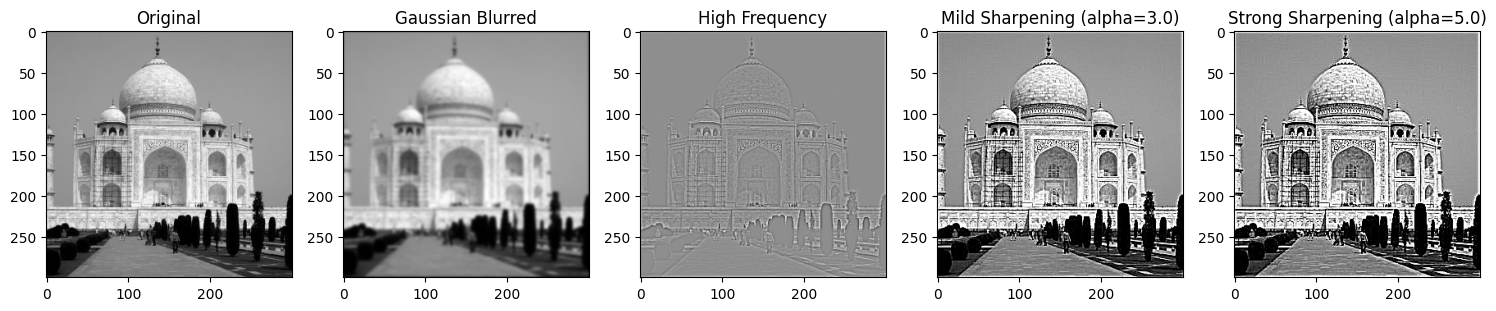

In [ ]:
#Part 2.1 sharpening filter 

def gaussian_filtered(img, sigma = 1.5, size=9):
    gaus_filter = gaussian_filter(sigma =sigma, size=size)
    blurred = convolve2d(img, gaus_filter, mode='same')
    return blurred 

def high_freq(img): 
    return img - gaussian_filtered(img)


def sharpening_filter(img, alpha=1.0): 
    sharpened =  img + alpha * high_freq(img)
    sharpened = np.clip(sharpened, 0, 255)
    return sharpened


def high_freq_display(image_path): 
    img = np.array(Image.open(image_path).convert('L')).astype(np.float64)

    blurred = gaussian_filtered(img)
    high_freq_img = high_freq(img)
    sharpened_mild = sharpening_filter(img, alpha=3.0)
    sharpened_strong = sharpening_filter(img, alpha=5.0)


    fig, axes = plt.subplots(1, 5, figsize=(15, 8))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')
    
    axes[1].imshow(blurred, cmap='gray')
    axes[1].set_title('Gaussian Blurred')

    axes[2].imshow(high_freq_img, cmap='gray')
    axes[2].set_title('High Frequency')

    axes[3].imshow(sharpened_mild, cmap='gray')
    axes[3].set_title('Mild Sharpening (alpha=3.0)')
    
    axes[4].imshow(sharpened_strong, cmap='gray')
    axes[4].set_title('Strong Sharpening (alpha=5.0)')
    
    
    
    plt.tight_layout()
    
    out_dir = "../web/photos"
    comparison_fig_path = os.path.join(out_dir, f"DoG_two_method_{int(time.time())}.jpg")
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

    plt.show()




high_freq_display('../data/taj.jpg')


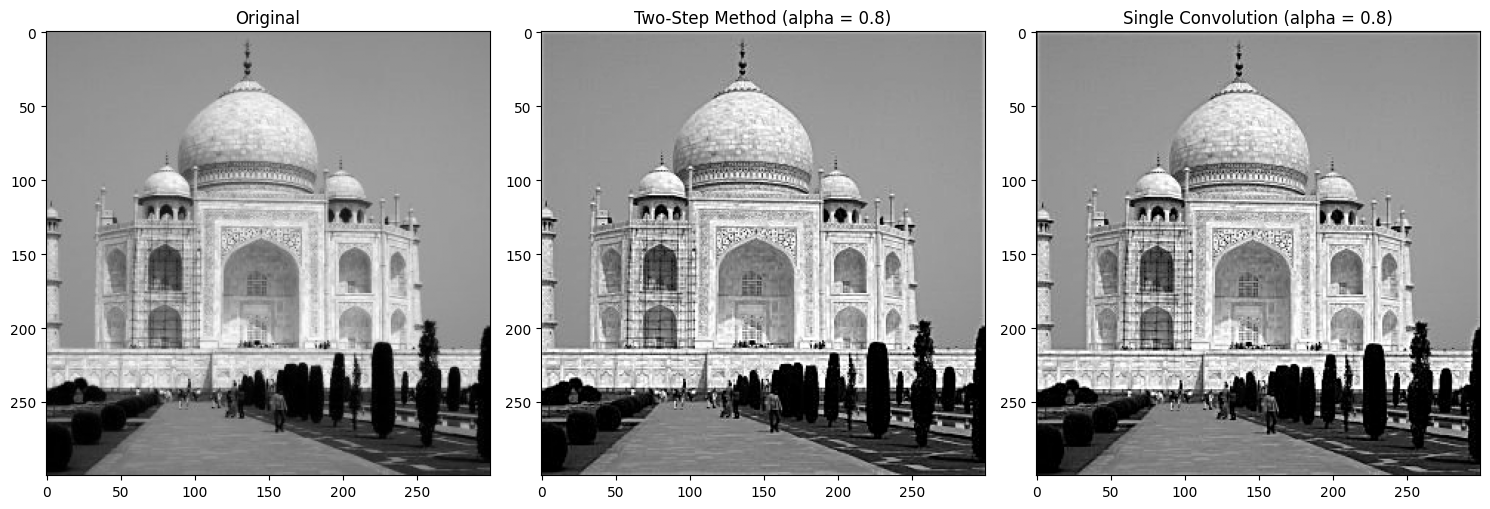

In [ ]:
#Part 2.1 single convolution 

def create_unsharp_mask_filter(alpha, sigma = 1.5, size = 16): 
    gaus_filter = gaussian_filter(sigma=1.5, size = 16)

    identity = np.zeros((size, size))
    center = size // 2
    identity[center, center] = 1.0  
    
    # img + alpha * (img - gaus) = (1+alpha)*img - alpha*gaus
    unsharp_filter = (1 + alpha) * identity - alpha * gaus_filter
    return unsharp_filter
   

def sharpening_one_conv(image_path, alpha): 
    img = np.array(Image.open(image_path).convert('L')).astype(np.float64)

    blurred = gaussian_filtered(img)
    sharpened_two_step = img + alpha * (img - blurred)
    sharpened_two_step = np.clip(sharpened_two_step, 0, 255)

    unsharp_filter = create_unsharp_mask_filter(alpha=alpha)
    sharpened_single = convolve2d(img, unsharp_filter, mode='same')
    sharpened_single = np.clip(sharpened_single, 0, 255)

    fig, axes = plt.subplots(1, 3, figsize=(15, 8))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')

    axes[1].imshow(sharpened_two_step, cmap='gray')
    axes[1].set_title('Two-Step Method (alpha = 0.8)')
    
    axes[2].imshow(sharpened_single, cmap='gray', )
    axes[2].set_title('Single Convolution (alpha = 0.8)')
    
    
    
    plt.tight_layout()
    
    out_dir = "../web/photos"
    comparison_fig_path = os.path.join(out_dir, f"sharpening_one_conv1_{int(time.time())}.jpg")
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

    plt.show()



sharpening_one_conv('../data/taj.jpg', 0.8)

In [ ]:
#Part2.2
import math
import numpy as np
import matplotlib.pyplot as plt
import skimage.transform as sktr



def get_points(im1, im2):
    print('Please select 2 points in each image for alignment.')
    plt.imshow(im1)
    p1, p2 = plt.ginput(2)
    plt.close()
    plt.imshow(im2)
    p3, p4 = plt.ginput(2)
    plt.close()
    return (p1, p2, p3, p4)

def recenter(im, r, c):
    R, C, _ = im.shape
    rpad = (int) (np.abs(2*r+1 - R))
    cpad = (int) (np.abs(2*c+1 - C))
    return np.pad(
        im, [(0 if r > (R-1)/2 else rpad, 0 if r < (R-1)/2 else rpad),
             (0 if c > (C-1)/2 else cpad, 0 if c < (C-1)/2 else cpad),
             (0, 0)], 'constant')

def find_centers(p1, p2):
    cx = np.round(np.mean([p1[0], p2[0]]))
    cy = np.round(np.mean([p1[1], p2[1]]))
    return cx, cy

def align_image_centers(im1, im2, pts):
    p1, p2, p3, p4 = pts
    h1, w1, b1 = im1.shape
    h2, w2, b2 = im2.shape
    
    cx1, cy1 = find_centers(p1, p2)
    cx2, cy2 = find_centers(p3, p4)

    im1 = recenter(im1, cy1, cx1)
    im2 = recenter(im2, cy2, cx2)
    return im1, im2

def rescale_images(im1, im2, pts):
    p1, p2, p3, p4 = pts
    len1 = np.sqrt((p2[1] - p1[1])**2 + (p2[0] - p1[0])**2)
    len2 = np.sqrt((p4[1] - p3[1])**2 + (p4[0] - p3[0])**2)
    dscale = len2/len1
    if dscale < 1:
        im1 = sktr.rescale(im1, dscale)
    else:
        im2 = sktr.rescale(im2, 1./dscale)
    return im1, im2

def rotate_im1(im1, im2, pts):
    p1, p2, p3, p4 = pts
    theta1 = math.atan2(-(p2[1] - p1[1]), (p2[0] - p1[0]))
    theta2 = math.atan2(-(p4[1] - p3[1]), (p4[0] - p3[0]))
    dtheta = theta2 - theta1
    im1 = sktr.rotate(im1, dtheta*180/np.pi)
    return im1, dtheta




# def match_img_size(im1, im2):
#     # Make images the same size
#     h1, w1, c1 = im1.shape
#     h2, w2, c2 = im2.shape
#     if h1 < h2:
#         im2 = im2[int(np.floor((h2-h1)/2.)) : -int(np.ceil((h2-h1)/2.)), :, :]
#     elif h1 > h2:
#         im1 = im1[int(np.floor((h1-h2)/2.)) : -int(np.ceil((h1-h2)/2.)), :, :]
#     if w1 < w2:
#         im2 = im2[:, int(np.floor((w2-w1)/2.)) : -int(np.ceil((w2-w1)/2.)), :]
#     elif w1 > w2:
#         im1 = im1[:, int(np.floor((w1-w2)/2.)) : -int(np.ceil((w1-w2)/2.)), :]
#     print(f"im1 shape: {im1.shape}, im2 shape: {im2.shape}")
#     assert im1.shape == im2.shape
#     return im1, im2

# def align_images(im1, im2):
#     pts = get_points(im1, im2)
#     im1, im2 = align_image_centers(im1, im2, pts)
#     im1, im2 = rescale_images(im1, im2, pts)
#     im1, angle = rotate_im1(im1, im2, pts)
#     im1, im2 = match_img_size(im1, im2)
#     return im1, im2

def match_img_size(im1, im2):
    """Center-crop im1 and im2 to the same spatial size.
       Handles grayscale (H,W), (H,W,1) and color (H,W,C)."""
    h1, w1 = im1.shape[:2]
    h2, w2 = im2.shape[:2]

    # crop height
    if h1 < h2:
        top = int(np.floor((h2 - h1) / 2.0))
        bottom = int(np.ceil((h2 - h1) / 2.0))
        im2 = im2[top:h2 - bottom, ...]
    elif h1 > h2:
        top = int(np.floor((h1 - h2) / 2.0))
        bottom = int(np.ceil((h1 - h2) / 2.0))
        im1 = im1[top:h1 - bottom, ...]

    # crop width
    if w1 < w2:
        left = int(np.floor((w2 - w1) / 2.0))
        right = int(np.ceil((w2 - w1) / 2.0))
        im2 = im2[:, left:w2 - right, ...]
    elif w1 > w2:
        left = int(np.floor((w1 - w2) / 2.0))
        right = int(np.ceil((w1 - w2) / 2.0))
        im1 = im1[:, left:w1 - right, ...]

    print(f"im1 shape: {im1.shape}, im2 shape: {im2.shape}")
    assert im1.shape[:2] == im2.shape[:2], f"Shapes still mismatch: {im1.shape} vs {im2.shape}"
    return im1, im2


def align_images(im1, im2):
    """Align im1 to im2 using selected points. Ensures consistent channels before matching size."""
    pts = get_points(im1, im2)
    im1, im2 = align_image_centers(im1, im2, pts)
    im1, im2 = rescale_images(im1, im2, pts)
    im1, angle = rotate_im1(im1, im2, pts)

    # If one is grayscale and the other is RGB, expand dims
    if im1.ndim == 2:
        im1 = im1[..., np.newaxis]
    if im2.ndim == 2:
        im2 = im2[..., np.newaxis]

    if im1.shape[-1] == 1 and im2.shape[-1] == 3:
        im1 = np.repeat(im1, 3, axis=-1)
    elif im2.shape[-1] == 1 and im1.shape[-1] == 3:
        im2 = np.repeat(im2, 3, axis=-1)

    im1, im2 = match_img_size(im1, im2)
    return im1, im2


if __name__ == "__main__":
    # 1. load the image
    # 2. align the two images by calling align_images
    # Now you are ready to write your own code for creating hybrid images!
    pass


In [118]:
# Part 2.2 Functions
import matplotlib.pyplot as plt
from skimage.color import rgb2gray, gray2rgb
  
%matplotlib qt

out_dir = "../web/photos"

def ensure_rgb(im):
    """Convert image to 3-channel RGB no matter what."""
    if im.ndim == 2:  # grayscale
        return np.stack([im]*3, axis=-1)
    elif im.ndim == 3 and im.shape[2] == 1:  # (H,W,1)
        return np.repeat(im, 3, axis=-1)
    elif im.ndim == 3 and im.shape[2] == 2:  # weird 2-channel case
        return np.dstack([im, np.zeros_like(im[...,0])])  # pad to 3
    elif im.ndim == 3 and im.shape[2] == 4:  # RGBA
        return im[...,:3]  # drop alpha
    return im  


def hybrid_image(im1, im2, sigma1, sigma2):
    # img1 = rgb2gray(im1)
    # img2 = rgb2gray(im2)
    

    # low_freq = gaussian_filtered(img1, sigma=sigma1)
    # blurred_img2 = gaussian_filtered(img2, sigma=sigma2)
    # high_freq = img2 - blurred_img2

    # hybrid = low_freq + 4 * high_freq
    # hybrid = np.clip(hybrid, 0, 1)
    # high_freq = np.clip(high_freq + 0.5, 0, 1) 

    im1 = ensure_rgb(im1)
    im2 = ensure_rgb(im2)

    low_freq = np.zeros_like(im2)
    high_freq = np.zeros_like(im1)

    for c in range(3):  # process each channel separately
        low_freq[..., c] = gaussian_filtered(im2[..., c], sigma=sigma1)
        blurred = gaussian_filtered(im1[..., c], sigma=sigma2)
        high_freq[..., c] = im1[..., c] - blurred

    hybrid = low_freq + 4 * high_freq
    hybrid = np.clip(hybrid, 0, 1)
    high_freq = np.clip(high_freq + 0.5, 0, 1)
    im1_gray = rgb2gray(im1)
    im2_gray = rgb2gray(im2)


    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  

    axes[0, 0].imshow(im1)
    axes[0, 0].set_title('Image 1 (High SF)')
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(im2)
    axes[1, 0].set_title('Image 2 (Low SF)')
    axes[1, 0].axis('off')

    im1_f = np.log(np.abs(np.fft.fftshift(np.fft.fft2(im1_gray))) + 1) 
    im2_f = np.log(np.abs(np.fft.fftshift(np.fft.fft2(im2_gray))) + 1)

    axes[0, 1].imshow(im1_f, cmap='hot')
    axes[0, 1].set_title('Image 1 Fourier Transform')
    axes[0, 1].axis('off')

    axes[1, 1].imshow(im2_f, cmap='hot')
    axes[1, 1].set_title('Image 2 Fourier Transform')
    axes[1, 1].axis('off')

    axes[0, 2].imshow(low_freq)
    axes[0, 2].set_title(f'Low Freq (σ={sigma1})')
    axes[0, 2].axis('off')

    axes[1, 2].imshow(high_freq)
    axes[1, 2].set_title(f'High Freq (σ={sigma2})')
    axes[1, 2].axis('off')


    plt.tight_layout()
    
    comparison_fig_path = os.path.join(out_dir, f"fourier_analysis_{int(time.time())}.jpg")
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.imshow(hybrid)
    plt.title(f'Hybrid Image (σ1={sigma1}, σ2={sigma2})')
    plt.axis('off')
    plt.tight_layout()
    
    hybrid_fig_path = os.path.join(out_dir, f"hybrid_image_{int(time.time())}.jpg")
    plt.savefig(hybrid_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    return hybrid, low_freq, high_freq

In [ ]:
from scipy.ndimage import convolve
def gaussian_stack(img, num_levels, sigma, sigma_multiplier):
    stack = []
    curr = img.astype(np.float64)
    stack.append(curr)
    for i in range(1, num_levels): 
        size = int(2 * np.ceil(3 * sigma) + 1) 
        kernel = gaussian_filter(sigma, size)
        if  len(img.shape) == 3: 
            filtered = np.zeros_like(curr)
            for channel in range(img.shape[2]):
                filtered[:, :, channel] = convolve(curr[:, :, channel], kernel, mode='reflect')
        else:  
            filtered = convolve2d(img, kernel, mode = "full", boundary = "fill", fillvalue = 0)
    
        stack.append(filtered)
        curr = filtered
        sigma *= sigma_multiplier 
    return stack
    

def laplacian_stack(img, num_levels, sigma, sigma_multiplier):
    gaussian_stack_list = gaussian_stack(img, num_levels, sigma, sigma_multiplier) 
    laplacian_stack_list = []

    for i in range(len(gaussian_stack_list) - 1):
        lap_level = gaussian_stack_list[i] - gaussian_stack_list[i + 1]
        laplacian_stack_list.append(lap_level)

    laplacian_stack_list.append(gaussian_stack_list[-1])

    return laplacian_stack_list, gaussian_stack_list

In [92]:
def display_stacks(gaussian_stack, laplacian_stack): 
    num_levels = len(gaussian_stack)

    fig, axes = plt.subplots(2, num_levels, figsize=(4*num_levels, 8))

    for i in range(num_levels):
        if len(gaussian_stack[i].shape) == 2: 
            axes[0, i].imshow(gaussian_stack[i], cmap='gray')
        else:  
            axes[0, i].imshow(np.clip(gaussian_stack[i], 0, 1))
        axes[0, i].set_title(f'Gaussian Level {i}')
        axes[0, i].axis('off')


        if i < len(laplacian_stack):
            lap_display = laplacian_stack[i]
            if len(lap_display.shape) == 2:  # Grayscale
                # Normalize for better visualization
                if lap_display.max() > lap_display.min():
                    lap_display = (lap_display - lap_display.min()) / (lap_display.max() - lap_display.min())
                axes[1, i].imshow(lap_display, cmap='gray')
            else:  # Color
                axes[1, i].imshow(np.clip(lap_display + 0.5, 0, 1))  
        axes[1, i].set_title(f'Laplacian Level {i}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    comparison_fig_path = os.path.join(out_dir, f"Gaussian_lap_stack_{int(time.time())}.jpg")
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
   
    plt.show()


img = plt.imread('../data/rnc.jpg') / 255.0

l, g = laplacian_stack(img, 5, 3.0, 2.0)
display_stacks(g, l)

In [ ]:
def hybrid_image2(im1, im2, sigma1, sigma2):
    # REMOVE these grayscale conversions:
    # img1 = rgb2gray(im1)  # ← DELETE
    # img2 = rgb2gray(im2)  # ← DELETE
    
    # Process each RGB channel separately
    hybrid_rgb = np.zeros_like(im1)
    low_freq_rgb = np.zeros_like(im1)
    high_freq_rgb = np.zeros_like(im1)
    
    for channel in range(3):  # Process R, G, B channels
        img1_channel = im1[:, :, channel]
        img2_channel = im2[:, :, channel]
        
        low_freq = gaussian_filtered(img1_channel, sigma=sigma1)
        blurred_img2 = gaussian_filtered(img2_channel, sigma=sigma2)
        high_freq = img2_channel - blurred_img2

        hybrid_channel = low_freq + 15 * high_freq
        hybrid_channel = np.clip(hybrid_channel, 0, 1)
        
        hybrid_rgb[:, :, channel] = hybrid_channel
        low_freq_rgb[:, :, channel] = low_freq
        high_freq_rgb[:, :, channel] = np.clip(high_freq + 0.5, 0, 1)
    
    # For Fourier transforms, you can still use grayscale or show one channel
    img1_gray = rgb2gray(im1)  # Only for Fourier display
    img2_gray = rgb2gray(im2)  # Only for Fourier display
    
    # Rest of your display code remains the same...
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  
    
    # Show original COLOR images
    axes[0, 0].imshow(im1)
    axes[0, 0].set_title('Image 1 (High SF)')
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(im2)
    axes[1, 0].set_title('Image 2 (Low SF)')
    axes[1, 0].axis('off')
    
    # Fourier transforms (can stay grayscale)
    im1_f = np.log(np.abs(np.fft.fftshift(np.fft.fft2(img1_gray))) + 1)
    im2_f = np.log(np.abs(np.fft.fftshift(np.fft.fft2(img2_gray))) + 1)
    
    axes[0, 1].imshow(im1_f, cmap='hot')
    axes[0, 1].set_title('Image 1 Fourier Transform')
    axes[0, 1].axis('off')
    
    axes[1, 1].imshow(im2_f, cmap='hot')
    axes[1, 1].set_title('Image 2 Fourier Transform')
    axes[1, 1].axis('off')
    
    # Show COLOR frequency components
    axes[0, 2].imshow(low_freq_rgb)
    axes[0, 2].set_title(f'Low Freq (σ={sigma1})')
    axes[0, 2].axis('off')
    
    axes[1, 2].imshow(high_freq_rgb)
    axes[1, 2].set_title(f'High Freq (σ={sigma2})')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Show COLOR hybrid result
    plt.figure(figsize=(10, 8))
    plt.imshow(hybrid_rgb)  # No cmap='gray' - show in color!
    plt.title(f'Hybrid Image (σ1={sigma1}, σ2={sigma2})')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return hybrid_rgb, low_freq_rgb, high_freq_rgb

In [151]:

# First load images
# high sf
im1 = plt.imread('../data/RO.jpg')/255.
# low sf
im2 = plt.imread('../data/SJ.jpg')/255

# Next align images (this code is provided, but may be improved)
im1_aligned, im2_aligned = align_images(im1, im2)
# im2_aligned = ensure_rgb(im2_aligned)
# im1_aligned = ensure_rgb(im1_aligned)

## You will provide the code below. Sigma1 and sigma2 are arbitrary 
## cutoff values for the high and low frequencies

sigma1 = 12.0
sigma2 = 3.0
hybrid, low_freq, high_freq = hybrid_image2(im2_aligned, im1_aligned, sigma1, sigma2)

## Compute and display Gaussian and Laplacian Pyramids
## You also need to supply this function
N = 5 # suggested number of pyramid levels (your choice)

#stacks(hybrid, N)

Please select 2 points in each image for alignment.
im1 shape: (1617, 1097, 3), im2 shape: (1617, 1097, 3)


In [ ]:
%matplotlib inline

In [ ]:
def compare_alpha_simple(im1, im2, sigma1, sigma2, alpha_values):

    img1 = rgb2gray(im1)
    img2 = rgb2gray(im2)
    
    low_freq = gaussian_filtered(img1, sigma=sigma1)
    blurred_img2 = gaussian_filtered(img2, sigma=sigma2)
    high_freq = img2 - blurred_img2
    
    n_alphas = len(alpha_values)
    fig, axes = plt.subplots(1, n_alphas, figsize=(4*n_alphas, 4))
    
    if n_alphas == 1:
        axes = [axes]  
    
    hybrids = []
    
    for i, alpha in enumerate(alpha_values):
        hybrid = low_freq + alpha * high_freq
        hybrid = np.clip(hybrid, 0, 1)
        hybrids.append(hybrid)
        
        axes[i].imshow(hybrid, cmap='gray')
        axes[i].set_title(f'α = {alpha}\n(σ1={sigma1}, σ2={sigma2})')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return hybrids

alpha_values = [1,2,3,4,5]
hybrids = compare_alpha_simple(im1_aligned, im2_aligned, sigma1=10.0, sigma2=7.0, alpha_values=alpha_values)

In [78]:
def laplacian_pyramid_blending_display(img1, img2, mask, num_levels=6, sigma=1.0, sigma_multiplier=2.0):
    lap_stack1, gauss_stack1 = laplacian_stack(img1, num_levels, sigma, sigma_multiplier)
    lap_stack2, gauss_stack2 = laplacian_stack(img2, num_levels, sigma, sigma_multiplier)
    
    mask_stack = gaussian_stack(mask, num_levels, sigma, sigma_multiplier)

    blended_pyramid = [] #middle column 
    for i in range(num_levels):
        blended_level = lap_stack1[i] * mask_stack[i] + lap_stack2[i] * (1 - mask_stack[i])
        blended_pyramid.append(blended_level)

    blended_result = np.sum(blended_pyramid, axis=0) #without axis collapse into one number

    fig, axes = plt.subplots(4, 3, figsize=(15, 20))
    axes[0, 0].imshow(np.clip(lap_stack1[0] + 0.5, 0, 1))         
    axes[0, 0].set_title('Image 1 - High Frequency (Level 0)')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(np.clip(lap_stack2[0] + 0.5, 0, 1))
    axes[0, 1].set_title('Image 2 - High Frequency (Level 0)')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(np.clip(blended_pyramid[0] + 0.5, 0, 1))
    axes[0, 2].set_title('Blended - High Frequency')
    axes[0, 2].axis('off')
    
    level_med = 2
    axes[1, 0].imshow(np.clip(lap_stack1[level_med] + 0.5, 0, 1))
    axes[1, 0].set_title(f'Image 1 - Medium Frequency (Level {level_med})')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(np.clip(lap_stack2[level_med] + 0.5, 0, 1))
    axes[1, 1].set_title(f'Image 2 - Medium Frequency (Level {level_med})')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(np.clip(blended_pyramid[level_med] + 0.5, 0, 1))
    axes[1, 2].set_title('Blended - Medium Frequency')
    axes[1, 2].axis('off')

    level_low = 4
    axes[2, 0].imshow(np.clip(lap_stack1[level_low] + 0.5, 0, 1))
    axes[2, 0].set_title(f'Image 1 - Low Frequency (Level {level_low})')
    axes[2, 0].axis('off')
    
    axes[2, 1].imshow(np.clip(lap_stack2[level_low] + 0.5, 0, 1))
    axes[2, 1].set_title(f'Image 2 - Low Frequency (Level {level_low})')
    axes[2, 1].axis('off')
    
    axes[2, 2].imshow(np.clip(blended_pyramid[level_low] + 0.5, 0, 1))
    axes[2, 2].set_title('Blended - Low Frequency')
    axes[2, 2].axis('off')

    axes[3, 0].imshow(img1 * mask)
    axes[3, 0].set_title('Original Image 1')
    axes[3, 0].axis('off')
    
    axes[3, 1].imshow(img2 * (1 - mask))
    axes[3, 1].set_title('Original Image 2')
    axes[3, 1].axis('off')
    
    axes[3, 2].imshow(np.clip(blended_result, 0, 1))
    axes[3, 2].set_title('Final Blended Result')
    axes[3, 2].axis('off')


    plt.tight_layout()
    comparison_fig_path = os.path.join(out_dir, f"stictch2.3appleorange_{int(time.time())}.jpg")
    plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

    plt.show()
    
    return blended_result, blended_pyramid

def create_blending_mask(shape, blend_region_width=50):
    h, w = shape[:2]
    mask = np.zeros((h, w))
    
    blend_start = w // 2 - blend_region_width // 2
    blend_end = blend_start + blend_region_width
    
    mask[:, :blend_start] = 1.0
    
    for x in range(blend_start, blend_end):
        alpha = 1.0 - (x - blend_start) / blend_region_width
        mask[:, x] = alpha
    
    if len(shape) == 3:
        mask = np.stack([mask] * shape[2], axis=-1)
    
    return mask


In [117]:
def rescale_img_part2(im1, im2):
    if im1.shape[-1] != 3:
        im1 = im1[:, :, :3]  
    
    if im2.shape[-1] != 3:
        im2 = im2[:, :, :3]
    
    # Get target dimensions that work for both images
    target_height = min(im1.shape[0], im2.shape[0])
    target_width = min(im1.shape[1], im2.shape[1])
    
    # Resize both images to the same target size
    im1_resized = sktr.resize(im1, (target_height, target_width))
    im2_resized = sktr.resize(im2, (target_height, target_width))
    
    # Double-check they have the same shape
    assert im1_resized.shape == im2_resized.shape, f"Shape mismatch: {im1_resized.shape} vs {im2_resized.shape}"
    
    print(f"Resized shapes: {im1_resized.shape} and {im2_resized.shape}")
    return im1_resized, im2_resized

def demonstrate_oraple_blending():
 
    apple = plt.imread('../data/head.jpg') / 255.0
    orange = plt.imread('../data/15307.jpg') / 255.0

    img1_resize, img2_resize = rescale_img_part2(apple, orange)

    # mask = create_blending_mask(img1_resize.shape)
    #mask = create_blurred_horizontal_mask(img1_resize.shape)
    mask = create_circular_blend_mask(img1_resize.shape, inner_radius=0.4, outer_radius=0.7)


    # Create the display
    blended, pyramid = laplacian_pyramid_blending_display(img1_resize, img2_resize, mask)
    
    return blended

final_blended = demonstrate_oraple_blending()

Resized shapes: (478, 478, 3) and (478, 478, 3)


In [99]:
def create_blurred_horizontal_mask(shape, transition_height=50):
    h, w = shape[:2]
    mask = np.zeros((h, w), dtype=np.float32)
    top_third = h // 4
    blend_start = top_third - transition_height // 2
    blend_end = top_third + transition_height // 2

    mask[:blend_start, :] = 1.0

    for y in range(blend_start, blend_end):
        alpha = 1.0 - (y - blend_start) / transition_height
        mask[y, :] = alpha

    if len(shape) == 3:
        mask = np.stack([mask] * shape[2], axis=-1)

    return mask

In [ ]:
def create_circular_blend_mask(shape, inner_radius=0.2, outer_radius=0.5):
  
    if len(shape) == 3:
        h, w, c = shape
    else:
        h, w = shape
        c = 1
    
    y, x = np.ogrid[:h, :w]
    center_y, center_x = h / 2, w / 2
    max_radius = np.sqrt(center_x**2 + center_y**2)
    
    distance = np.sqrt((x - center_x)**2 + (y - center_y)**2) / max_radius
    
    mask = np.ones((h, w))
    
    mask[distance <= inner_radius] = 0.0
    
    blend_region = (distance > inner_radius) & (distance < outer_radius)
    blend_values = (distance[blend_region] - inner_radius) / (outer_radius - inner_radius)
    mask[blend_region] = blend_values
    
    
    if c > 1:
        mask = np.stack([mask] * c, axis=-1)
    
    return mask